Combined shape: (945, 384)
X shape: (945, 378)
y shape: (945, 3)
flute_1 -> MSE: 209.6637, MAPE: 3.39%
flute_2 -> MSE: 311.1681, MAPE: 4.34%
flute_3 -> MSE: 223.3176, MAPE: 3.68%


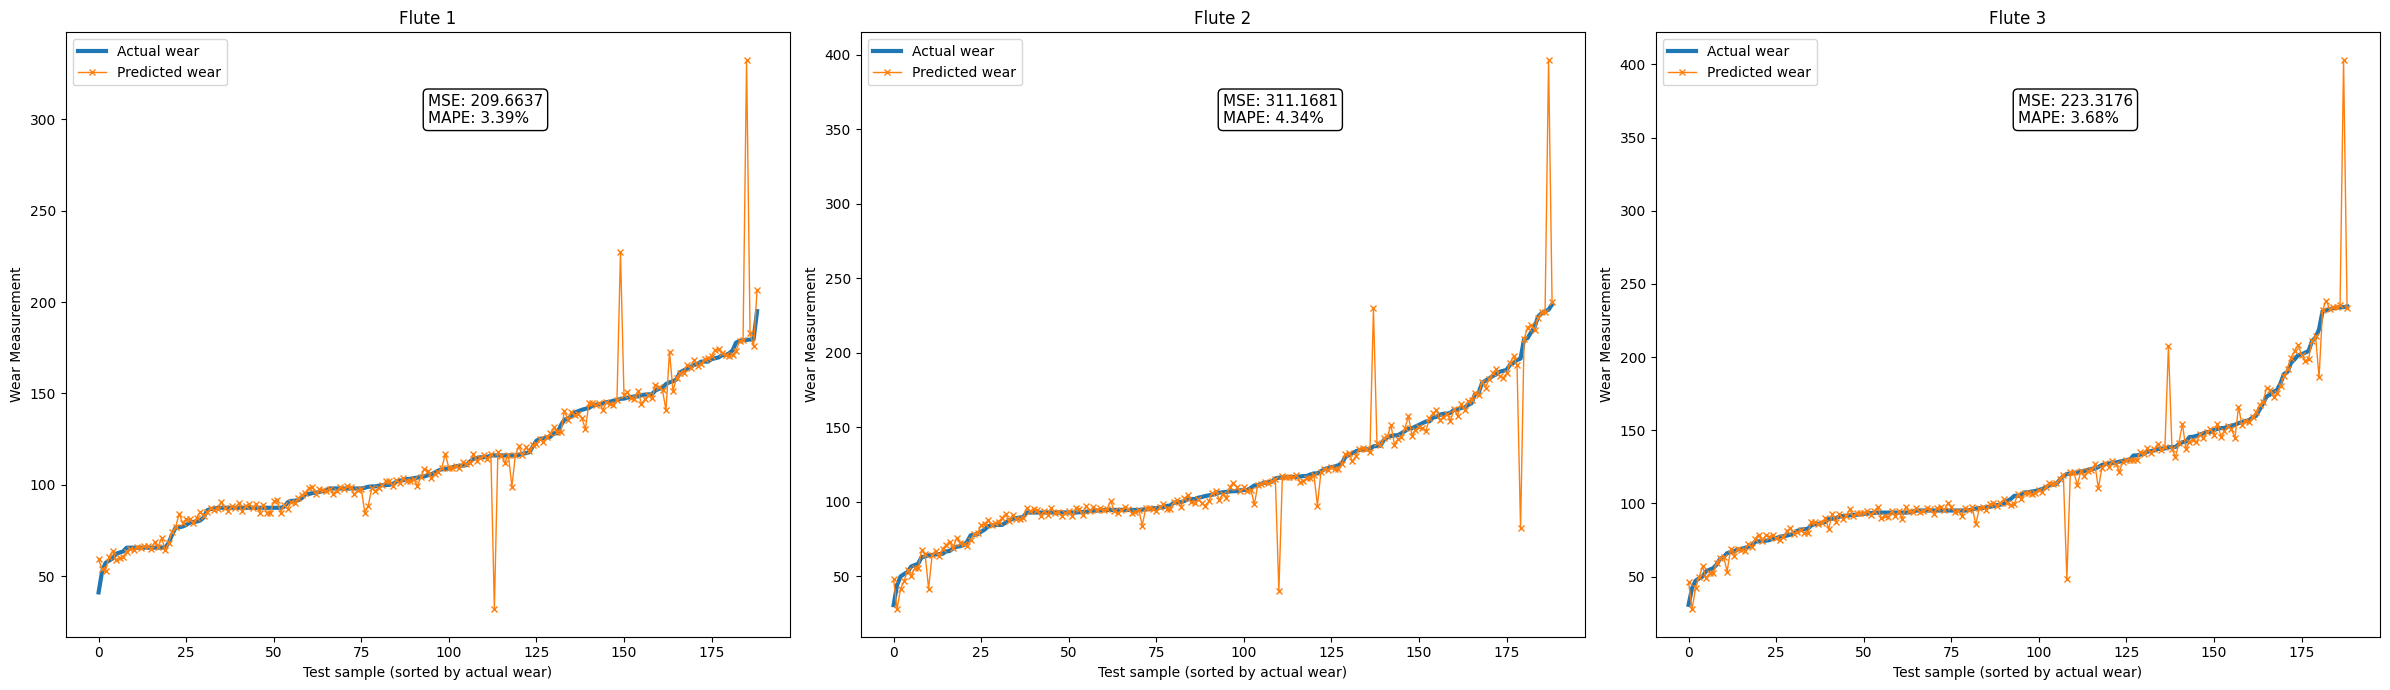

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# ============================================================
# STEP 1: Combine all three cutters
# ============================================================
df_c1 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c1_aggregated_features.csv")
df_c4 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c4_aggregated_features.csv")
df_c6 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c6_aggregated_features.csv")

df_c1["cutter"] = "C1"
df_c4["cutter"] = "C4"
df_c6["cutter"] = "C6"

df_combined = pd.concat([df_c1, df_c4, df_c6], ignore_index=True)
print("Combined shape:", df_combined.shape)  # (945, 384)

# ============================================================
# STEP 2: Define X and y
# ============================================================
y = df_combined[["flute_1", "flute_2", "flute_3"]]

X = df_combined.drop(
    columns=["cut_number", "flute_1", "flute_2", "flute_3", "max_wear", "cutter"]
)

print("X shape:", X.shape)  # (945, 378)
print("y shape:", y.shape)  # (945, 3)

# ============================================================
# STEP 3: Train/test split
# ============================================================
# shuffle=False keeps cuts in order within each cutter, but since we
# concatenated 3 cutters back-to-back, a plain sequential split would put
# all of C6 in the test set. So we shuffle here since rows aren't one
# continuous wear sequence anymore.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# ============================================================
# STEP 4: Pipeline with scaling (important for Linear/Lasso Regression)
# ============================================================
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# ============================================================
# STEP 5: Evaluate per flute
# ============================================================
for i, flute in enumerate(["flute_1", "flute_2", "flute_3"]):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    mape = mean_absolute_percentage_error(y_test.iloc[:, i], y_pred[:, i]) * 100
    print(f"{flute} -> MSE: {mse:.4f}, MAPE: {mape:.2f}%")

# ============================================================
# STEP 6: Plot actual vs predicted (test set, sorted for readability)
# ============================================================
def plot_predictions(y_actual, y_pred):
    y_actual = np.array(y_actual)
    y_pred = np.array(y_pred)
    n_targets = y_actual.shape[1]
    flute_labels = [f"Flute {i+1}" for i in range(n_targets)]

    fig, axes = plt.subplots(1, n_targets, figsize=(24, 7))
    for i in range(n_targets):
        ax = axes[i]
        actual = y_actual[:, i]
        pred = y_pred[:, i]

        mse = mean_squared_error(actual, pred)
        mape = mean_absolute_percentage_error(actual, pred) * 100

        order = np.argsort(actual)  # sort so the "actual" line trends smoothly
        ax.plot(actual[order], label="Actual wear", linewidth=3, color="tab:blue")
        ax.plot(pred[order], label="Predicted wear", marker="x",
                 markersize=4, linewidth=1, color="tab:orange")

        ax.set_title(flute_labels[i])
        ax.set_xlabel("Test sample (sorted by actual wear)")
        ax.set_ylabel("Wear Measurement")
        ax.legend(loc="upper left")
        ax.text(0.5, 0.85, f"MSE: {mse:.4f}\nMAPE: {mape:.2f}%",
                transform=ax.transAxes, fontsize=11,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

    plt.tight_layout()
    plt.show()

plot_predictions(y_test, y_pred)